In [1]:
from qiskit import *
from math import log2

In [2]:
def get_divergence(a, b):
    n = int(log2(a)) + 1
    divergence = []
    for i in range(n):
        if ((a >> i) & 1) != ((b >> i) & 1):
            divergence.append(i)
    return divergence

In [3]:
def get_a1(a, b):
    divergence = get_divergence(a, b)
    div = divergence[1:]
    for idx in div:
        a = a ^ (1 << idx)
    return a, divergence

In [4]:
def get_a2(a, b):
    a1, divergence = get_a1(a, b)
    a2 = a1 ^ (1 << divergence[0])
    return a2

In [5]:
def pivot_divergence(piv_idx, divergence, n):
    quantum_circuit = QuantumCircuit(n)
    for idx in divergence:
        if idx != piv_idx:
            quantum_circuit.cx(piv_idx, idx)
    return quantum_circuit

In [6]:
def pivot_fix(piv_idx, divergence, a1, n):
    divergence.remove(piv_idx)
    controls = ""
    for idx in divergence:
        if((a1 >> idx) & 1):
            controls += "0"
        else:
            controls += "1"
    quantum_circuit = QuantumCircuit(n)
    quantum_circuit.mcx(divergence, piv_idx, ctrl_state=controls)
    return quantum_circuit

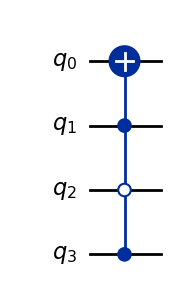

In [7]:
pivot_fix(0, [0,1,2,3], 4, 4).draw("mpl")

In [11]:
def cnot_reduction(a, b):

    n = int(log2(a)) + 1

    if a == b: return QuantumCircuit(n)

    a1, divergence = get_a1(a, b)
    pix_idx = divergence[0]

    quantum_circuit = QuantumCircuit(n)
    
    quantum_circuit.append(pivot_divergence(pix_idx, divergence, n), range(n))
    quantum_circuit.append(pivot_fix(pix_idx, divergence, a1, n), range(n))
    quantum_circuit.append(pivot_divergence(pix_idx, divergence, n), range(n))

    return quantum_circuit

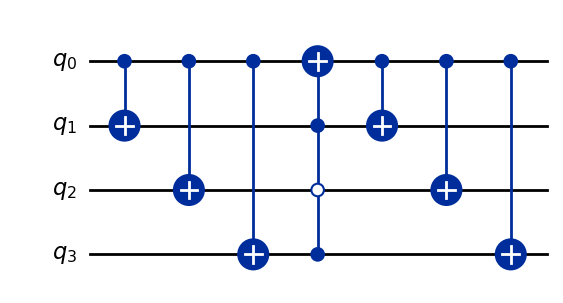

In [13]:
cnot_reduction(0b1010, 0b0101).decompose().draw("mpl")